# EDA - CIC-IDS2017

Análisis exploratorio del dataset

Incluye:
1. Una breve descripción de lo que se está midiendo
2. El cálculo y los resultados exportados
3. Una nota final en la que se explica cómo interpretar los resultados para planificar las características de entrada

In [2]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np  
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

def detect_project_root(start: Path) -> Path:
    """Find the IDS project root robustly from notebook kernels."""
    start = start.resolve()

    def looks_like_ids_root(p: Path) -> bool:
        return (p / "data/processed").exists() and (p / "notebooks").exists() and (p / "src").exists()

    # 1) Walk current path and parents.
    for p in [start, *start.parents]:
        if looks_like_ids_root(p):
            return p

    # 2) Common case: kernel started one level above the repo folder.
    for p in [start, *start.parents]:
        candidate = p / "ids"
        if looks_like_ids_root(candidate):
            return candidate

    raise FileNotFoundError(
        f"Could not locate IDS project root from cwd={start}. "
        "Expected a directory containing data/processed, notebooks, and src."
    )


ROOT = detect_project_root(Path.cwd())
print(f"Resolved project root: {ROOT}")
CFG = {
    "dataset": "CIC",
    "label_col": "attack_type",
    "normal_label": "BENIGN",
    "drop_cols": ["Label", "attack_label", "attack_type", "source_file"],
    "train_path": ROOT / "data/processed/CIC-IDS2017/splits/train/data.parquet",
    "val_path": ROOT / "data/processed/CIC-IDS2017/splits/val/data.parquet",
    "test_path": ROOT / "data/processed/CIC-IDS2017/splits/test/data.parquet",
    "out_fig_dir": ROOT / "reports/figures/cic/eda",
    "out_tbl_dir": ROOT / "reports/metrics/cic/eda",
}

CFG["out_fig_dir"].mkdir(parents=True, exist_ok=True)
CFG["out_tbl_dir"].mkdir(parents=True, exist_ok=True)


def ks_statistic(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) == 0 or len(b) == 0:
        return np.nan
    a = np.sort(a)
    b = np.sort(b)
    values = np.sort(np.concatenate([a, b]))
    cdf_a = np.searchsorted(a, values, side="right") / len(a)
    cdf_b = np.searchsorted(b, values, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))


print("CIC EDA setup ready.")

Resolved project root: /home/freuer/Documents/projects/ai/ids
CIC EDA setup ready.


## Perfilamiento de splits

Carga los splits para entrenamiento, validación y pruebas para reportar tamaño, valores nulos y duplicados

In [3]:
train_df = pd.read_parquet(CFG["train_path"])
val_df = pd.read_parquet(CFG["val_path"])
test_df = pd.read_parquet(CFG["test_path"])

splits = {"train": train_df, "val": val_df, "test": test_df}
profile = []
for name, df in splits.items():
    profile.append(
        {
            "split": name,
            "rows": len(df),
            "columns": df.shape[1],
            "missing_total": int(df.isna().sum().sum()),
            "duplicate_rows": int(df.duplicated().sum()),
        }
    )

profile_df = pd.DataFrame(profile)
display(profile_df)
profile_df.to_csv(CFG["out_tbl_dir"] / "split_profile.csv", index=False)

,split,rows,columns,missing_total,duplicate_rows
0,train,1619667,81,0,0
1,val,231381,81,0,0
2,test,462762,81,0,0


- Un elevado número de duplicados en cualquier segmentación indica un posible riesgo de fuga de datos.
- Si los tamaños de las segmentaciones difieren mucho entre sí, puede ser necesario revisar la estrategia de segmentación.
- La existencia de grandes totales faltantes sugiere que es necesario establecer reglas de imputación o eliminación tempranas.

## Revisión de esquema y tipos de los datos

Una tabla de esquema explícita para la división de entrenamiento con el tipo de datos de cada columna, estadísticas de valores nulos y uso de memoria. Además, genera un resumen del recuento de tipos de datos.

In [5]:
schema_df = pd.DataFrame(
    {
        "column": train_df.columns,
        "dtype": train_df.dtypes.astype(str).values,
        "non_null_count": train_df.notna().sum().values,
        "null_count": train_df.isna().sum().values,
        "null_ratio": train_df.isna().mean().values,
        "memory_mb": (train_df.memory_usage(deep=True).reindex(train_df.columns) / (1024 ** 2)).values,
    }
).sort_values(["dtype", "null_ratio", "column"], ascending=[True, False, True])

dtype_counts_df = (
    schema_df.groupby("dtype", as_index=False)["column"]
    .count()
    .rename(columns={"column": "n_columns"})
    .sort_values("n_columns", ascending=False)
)

schema_out = CFG["out_tbl_dir"] / "schema_train_columns.csv"
dtype_out = CFG["out_tbl_dir"] / "schema_train_dtype_counts.csv"

schema_df.to_csv(schema_out, index=False)
dtype_counts_df.to_csv(dtype_out, index=False)

print(f"Saved: {schema_out}")
print(f"Saved: {dtype_out}")
display(dtype_counts_df)
display(schema_df.head(30))

Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/eda/schema_train_columns.csv
Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/cic/eda/schema_train_dtype_counts.csv


,dtype,n_columns
3,int32,26
0,float32,22
5,int8,19
2,int16,7
6,object,3
1,float64,2
4,int64,2


,column,dtype,non_null_count,null_count,null_ratio,memory_mb
69,Active Mean,float32,1619667,0,0.0,6.178539
70,Active Std,float32,1619667,0,0.0,6.178539
54,Avg Bwd Segment Size,float32,1619667,0,0.0,6.178539
53,Avg Fwd Segment Size,float32,1619667,0,0.0,6.178539
52,Avg Packet Size,float32,1619667,0,0.0,6.178539
26,Bwd IAT Mean,float32,1619667,0,0.0,6.178539
27,Bwd IAT Std,float32,1619667,0,0.0,6.178539
12,Bwd Packet Length Mean,float32,1619667,0,0.0,6.178539
13,Bwd Packet Length Std,float32,1619667,0,0.0,6.178539
37,Bwd Packets/s,float32,1619667,0,0.0,6.178539


- `dtype` La distribución te indica si contiene principalmente datos numéricos o si requiere una codificación fuerte de datos categóricos.
- `null_ratio` Columnas que deberían "rellenarse" con imputación.
- `memory_mb` Las columnas son candidatas para la conversión a un tipo inferior o para un uso selectivo en los primeros prototipos.

## Distribución de clases (Binario y Multiclase)

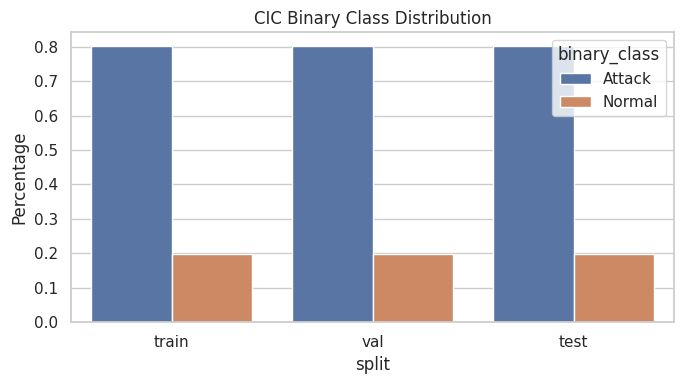

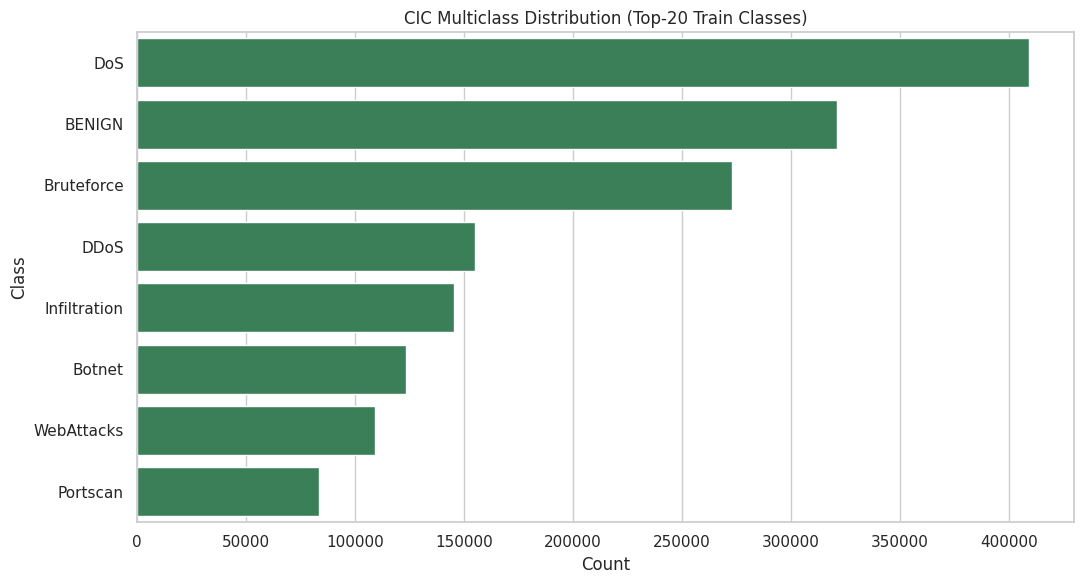

,class,count,pct
0,DoS,409494,0.252826
1,BENIGN,321182,0.198301
2,Bruteforce,272800,0.168430
3,DDoS,154884,0.095627
4,Infiltration,145341,0.089735
5,Botnet,123226,0.076081
6,WebAttacks,109074,0.067343
7,Portscan,83666,0.051656


In [6]:
label_col = CFG["label_col"]
normal_label = CFG["normal_label"]

rows = []
for split_name, df in splits.items():
    bin_counts = pd.Series(np.where(df[label_col] == normal_label, "Normal", "Attack")).value_counts()
    for cls, cnt in bin_counts.items():
        rows.append({"split": split_name, "binary_class": cls, "count": int(cnt), "pct": float(cnt / len(df))})

binary_df = pd.DataFrame(rows)

plt.figure(figsize=(7, 4))
sns.barplot(data=binary_df, x="split", y="pct", hue="binary_class")
plt.title("CIC Binary Class Distribution")
plt.ylabel("Percentage")
plt.tight_layout()
plt.savefig(CFG["out_fig_dir"] / "binary_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

train_multiclass = train_df[label_col].value_counts().rename_axis("class").reset_index(name="count")
train_multiclass["pct"] = train_multiclass["count"] / train_multiclass["count"].sum()

plt.figure(figsize=(11, 6))
sns.barplot(data=train_multiclass.head(20), x="count", y="class", color="seagreen")
plt.title("CIC Multiclass Distribution (Top-20 Train Classes)")
plt.xlabel("Count")
plt.ylabel("Class")
plt.tight_layout()
plt.savefig(CFG["out_fig_dir"] / "multiclass_distribution_top20_train.png", dpi=150, bbox_inches="tight")
plt.show()

train_multiclass.to_csv(CFG["out_tbl_dir"] / "multiclass_distribution_train.csv", index=False)
binary_df.to_csv(CFG["out_tbl_dir"] / "binary_distribution_by_split.csv", index=False)

display(train_multiclass.head(25))

## Caracteristicas numéricas

Perfila caracteristicas numéricas por indice de datos faltantes, varianza y valores atipicos

Se identifica las columnas que deberían removerse, transformarse o por lo menos monitorearse antes de ingresarlos al modelo

In [8]:
X_train = train_df.drop(columns=CFG["drop_cols"], errors="ignore")
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

missing_ratio = X_train[num_cols].isna().mean().sort_values(ascending=False)
variance = X_train[num_cols].var().sort_values()
quantiles = X_train[num_cols].quantile([0.01, 0.25, 0.5, 0.75, 0.99]).T
quantiles.columns = ["q01", "q25", "q50", "q75", "q99"]
quantiles["iqr"] = quantiles["q75"] - quantiles["q25"]
quantiles["outlier_signal"] = (quantiles["q99"] - quantiles["q01"]) / quantiles["iqr"].replace(0, np.nan)

missing_ratio.rename("missing_ratio").to_csv(CFG["out_tbl_dir"] / "missing_ratio_train.csv")
variance.rename("variance").to_csv(CFG["out_tbl_dir"] / "variance_train.csv")
quantiles.sort_values("outlier_signal", ascending=False).to_csv(CFG["out_tbl_dir"] / "numeric_quantiles_train.csv")

print(f"Numeric features: {len(num_cols)}")
print("Top missing features")
display(missing_ratio.head(10).to_frame("missing_ratio"))
print("Top low-variance features")
display(variance.head(10).to_frame("variance"))
print("Top outlier-signal features")
display(quantiles.sort_values("outlier_signal", ascending=False).head(10))

Numeric features: 77
Top missing features


,missing_ratio
Protocol,0.0
CWE Flag Count,0.0
Fwd Avg Packets/Bulk,0.0
Fwd Avg Bytes/Bulk,0.0
Avg Bwd Segment Size,0.0
Avg Fwd Segment Size,0.0
Avg Packet Size,0.0
Down/Up Ratio,0.0
ECE Flag Count,0.0
URG Flag Count,0.0


Top low-variance features


,variance
Bwd Avg Bulk Rate,0.000000
Bwd Avg Packets/Bulk,0.000000
Bwd Avg Bytes/Bulk,0.000000
Fwd Avg Bulk Rate,0.000000
Fwd Avg Packets/Bulk,0.000000
Fwd Avg Bytes/Bulk,0.000000
Bwd PSH Flags,0.000000
Bwd URG Flags,0.000000
CWE Flag Count,0.000009
Fwd URG Flags,0.000009


Top outlier-signal features


,q01,q25,q50,q75,q99,iqr,outlier_signal
Bwd IAT Min,0.0,0.000000,3.000000,48.000000,5.900000e+07,48.000000,1.229167e+06
Fwd IAT Min,0.0,1.000000,3.000000,56.000000,6.406104e+07,55.000000,1.164746e+06
Flow IAT Min,0.0,3.000000,4.000000,78.000000,9.966327e+05,75.000000,1.328844e+04
Bwd IAT Mean,0.0,0.000000,4.000000,39384.099609,5.900000e+07,39384.099609,1.498066e+03
Bwd IAT Std,0.0,0.000000,0.000000,48109.792969,4.030000e+07,48109.792969,8.376673e+02
Bwd IAT Max,0.0,0.000000,4.000000,139829.000000,9.920000e+07,139829.000000,7.094380e+02
Bwd IAT Total,0.0,0.000000,4.000000,213275.000000,1.173046e+08,213275.000000,5.500158e+02
Bwd Packets/s,0.0,0.178819,16.593380,93.237404,4.878049e+04,93.058585,5.241912e+02
Init Bwd Win Bytes,-1.0,-1.000000,-1.000000,235.000000,5.256000e+04,236.000000,2.227161e+02
Flow Bytes/s,0.0,119.465792,3151.183166,32978.788420,4.500000e+06,32859.322628,1.369474e+02


- Las variables con un alto índice de valores perdidos deben someterse a reglas de imputación explícitas o descartarse.
- Las variables con una varianza cercana a cero suelen aportar poca información discriminatoria.
- Las variables con un alto contenido de valores atípicos pueden requerir un escalado robusto o un recorte.

## Revisión de las categorías

cardinalidad categórica e indice de catergorias raras

Las categorías de alta cardinalidad y dispersas influyen considerablemente en las decisiones de codificación y en la solidez del modelo.

In [11]:
X_all = train_df.drop(columns=CFG["drop_cols"], errors="ignore")
cat_cols = X_all.select_dtypes(exclude=[np.number]).columns.tolist()

cat_rows = []
for col in cat_cols:
    s = X_all[col].astype("string")
    vc = s.value_counts(dropna=False)
    rare_count = int(vc[vc <= 5].sum())
    cat_rows.append(
        {
            "feature": col,
            "n_unique": int(s.nunique(dropna=False)),
            "missing_ratio": float(s.isna().mean()),
            "rare_ratio_le_5": float(rare_count / max(len(s), 1)),
        }
    )

cat_audit_df = pd.DataFrame(cat_rows).sort_values(["n_unique", "rare_ratio_le_5"], ascending=[False, False]) if cat_rows else pd.DataFrame(columns=["feature", "n_unique", "missing_ratio", "rare_ratio_le_5"])
cat_audit_df.to_csv(CFG["out_tbl_dir"] / "categorical_audit_train.csv", index=False)
display(cat_audit_df.head(20))

,feature,n_unique,missing_ratio,rare_ratio_le_5


- Un valor elevado de `n_unique` sugiere que se debe realizar una codificación cuidadosa (o aplicar más adelante un hash de características o una política de objetivos).
- Un valor elevado de `rare_ratio_le_5` indica que hay categorías dispersas con mucho ruido que podrían necesitar agruparse.
- Un alto porcentaje de valores perdidos en los campos categóricos requiere una estrategia de rellenado explícita.

## Patrones de datos faltantes

Calcula la ausencia de datos por variable y la coausencia entre pares de variables entre las columnas con mayor número de valores perdidos.

La coausencia indica lagunas sistemáticas en la recopilación de datos, no valores perdidos aleatorios.

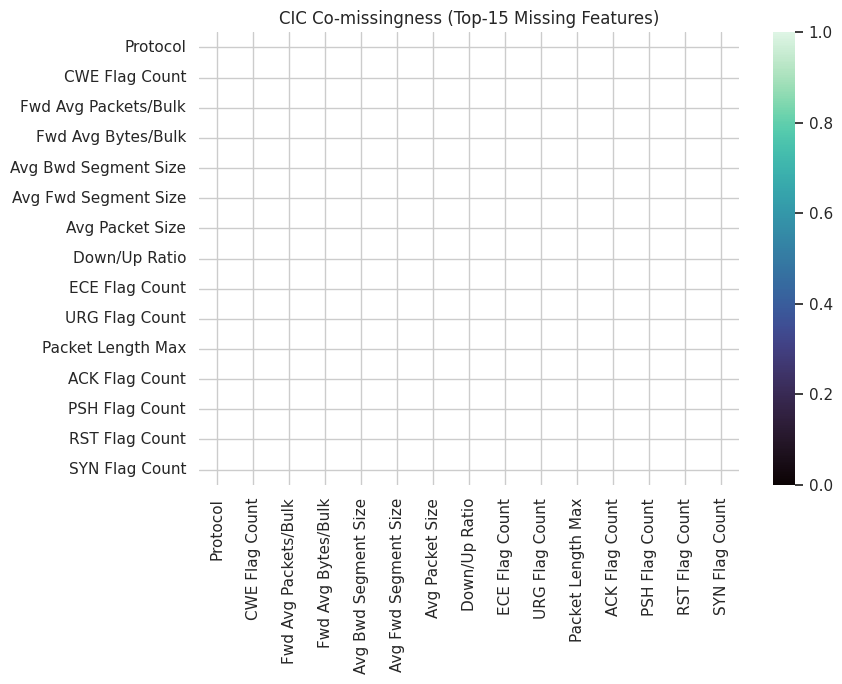

,missing_ratio
Protocol,0.0
CWE Flag Count,0.0
Fwd Avg Packets/Bulk,0.0
Fwd Avg Bytes/Bulk,0.0
Avg Bwd Segment Size,0.0
Avg Fwd Segment Size,0.0
Avg Packet Size,0.0
Down/Up Ratio,0.0
ECE Flag Count,0.0
URG Flag Count,0.0


In [12]:
missing_by_feature = X_all.isna().mean().sort_values(ascending=False)
missing_by_feature.to_csv(CFG["out_tbl_dir"] / "missing_ratio_all_features_train.csv", header=["missing_ratio"])

top_missing_cols = missing_by_feature.head(15).index.tolist()
if top_missing_cols:
    miss_matrix = X_all[top_missing_cols].isna().astype(int).corr()
    plt.figure(figsize=(9, 7))
    sns.heatmap(miss_matrix, cmap="mako", vmin=0, vmax=1)
    plt.title("CIC Co-missingness (Top-15 Missing Features)")
    plt.tight_layout()
    plt.savefig(CFG["out_fig_dir"] / "co_missingness_top15.png", dpi=150, bbox_inches="tight")
    plt.show()

display(missing_by_feature.head(20).to_frame("missing_ratio"))

- Si faltan las mismas columnas de forma conjunta, es preferible utilizar reglas de imputación que tengan en cuenta los bloques.
- Las variables con un alto índice de datos faltantes que se repite en muchas filas son candidatas a ser eliminadas.
- Los datos faltantes no aleatorios deben documentarse como una restricción en la recopilación de datos.

## Comprobación de fugas

Comprueba si hay solapamientos exactos entre los conjuntos de entrenamiento, validación y prueba.

Cualquier solapamiento entre los conjuntos puede sesgar la evaluación e invalidar las conclusiones.

In [14]:
def row_hash_set(df: pd.DataFrame) -> set:
    h = pd.util.hash_pandas_object(df.fillna("__NA__"), index=False)
    return set(h.astype("uint64").tolist())

train_hash = row_hash_set(train_df)
val_hash = row_hash_set(val_df)
test_hash = row_hash_set(test_df)

leakage_df = pd.DataFrame(
    [
        {"pair": "train_val", "overlap_rows": len(train_hash & val_hash)},
        {"pair": "train_test", "overlap_rows": len(train_hash & test_hash)},
        {"pair": "val_test", "overlap_rows": len(val_hash & test_hash)},
    ]
)
leakage_df.to_csv(CFG["out_tbl_dir"] / "split_overlap_exact_rows.csv", index=False)
display(leakage_df)

,pair,overlap_rows
0,train_val,0
1,train_test,0
2,val_test,0


- Cualquier solapamiento distinto de cero debe considerarse un riesgo de fuga de datos.
- Es necesario resolver la fuga de datos antes de dar por fiables las métricas del modelo posterior.
- Mantenga esta comprobación como un paso obligatorio en futuras actualizaciones de datos.

## Valores atípicos

Calcula las tasas de valores atípicos por característica utilizando límites robustos del intervalo intercuartílico (IQR).

Las características con un gran número de valores atípicos pueden requerir recorte, escalado robusto o transformación logarítmica antes de su incorporación al modelo.

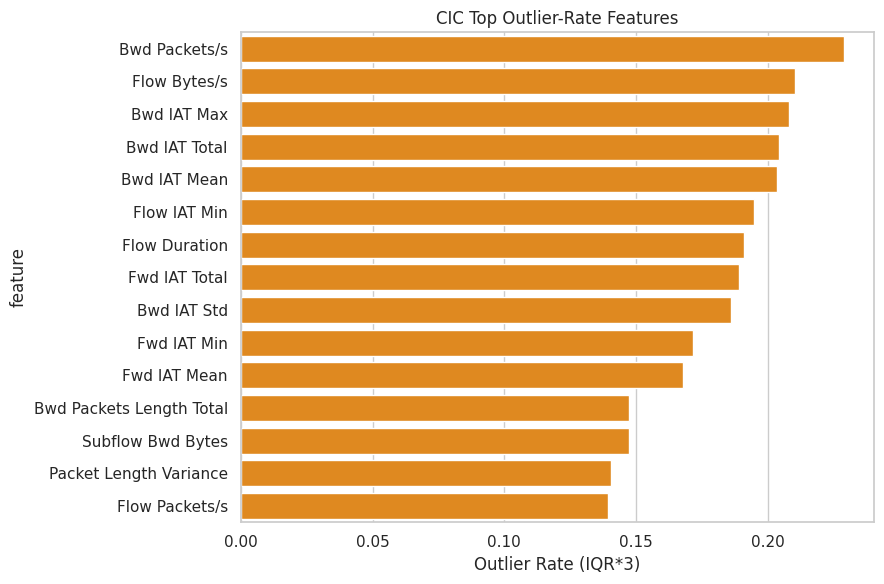

,feature,outlier_rate_iqr3
37,Bwd Packets/s,0.228983
14,Flow Bytes/s,0.210244
28,Bwd IAT Max,0.208261
25,Bwd IAT Total,0.204372
26,Bwd IAT Mean,0.203469
19,Flow IAT Min,0.194810
1,Flow Duration,0.191052
20,Fwd IAT Total,0.189013
27,Bwd IAT Std,0.186275
24,Fwd IAT Min,0.171761


In [15]:
out_rows = []
for col in num_cols:
    s = X_train[col].dropna()
    if len(s) == 0:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        rate = 0.0
    else:
        lo = q1 - 3.0 * iqr
        hi = q3 + 3.0 * iqr
        rate = float(((s < lo) | (s > hi)).mean())
    out_rows.append({"feature": col, "outlier_rate_iqr3": rate})

outlier_df = pd.DataFrame(out_rows).sort_values("outlier_rate_iqr3", ascending=False)
outlier_df.to_csv(CFG["out_tbl_dir"] / "outlier_rate_iqr3_train.csv", index=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=outlier_df.head(15), x="outlier_rate_iqr3", y="feature", color="darkorange")
plt.title("CIC Top Outlier-Rate Features")
plt.xlabel("Outlier Rate (IQR*3)")
plt.tight_layout()
plt.savefig(CFG["out_fig_dir"] / "outlier_rate_top15.png", dpi=150, bbox_inches="tight")
plt.show()

display(outlier_df.head(20))

- Las características con una alta tasa de valores atípicos deben revisarse para detectar posibles recortes o escalas logarítmicas.
- Si muchas de las características con valores atípicos más destacados se solapan con características que han sufrido desviaciones, se debe dar prioridad a un preprocesamiento robusto.
- Conserva los valores brutos en los archivos de registro para garantizar la trazabilidad antes de la transformación.

## Análisis comparativo de caracteristicas numéricas

Mide el sesgo entre el conjunto de entrenamiento y los conjuntos de validación y prueba utilizando estadísticas de KS en las características numéricas con mayor varianza.

Las características con una fuerte deriva en la división pueden generalizarse mal si se utilizan sin estabilización.

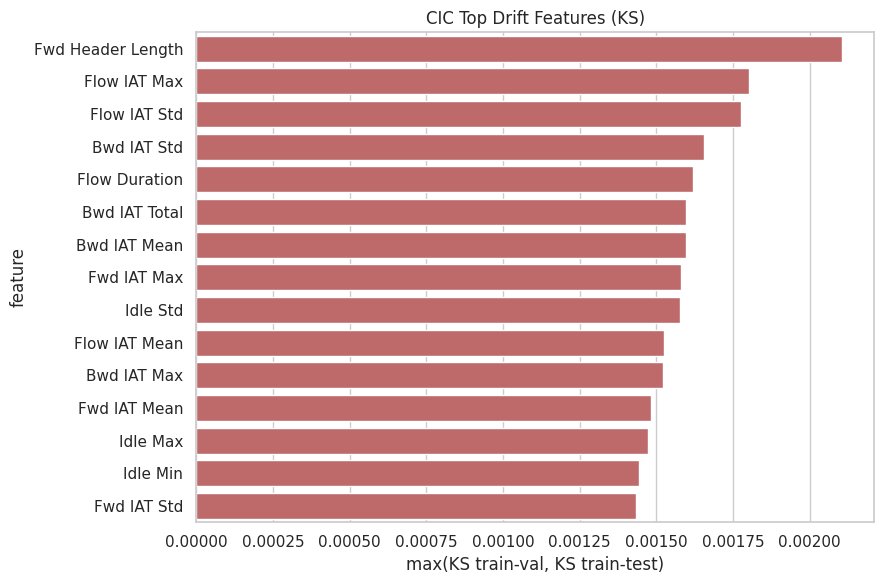

,feature,ks_train_val,ks_train_test,max_ks
14,Fwd Header Length,0.002105,0.000636,0.002105
4,Flow IAT Max,0.001802,0.000911,0.001802
15,Flow IAT Std,0.001776,0.001289,0.001776
17,Bwd IAT Std,0.001559,0.001656,0.001656
0,Flow Duration,0.001621,0.000916,0.001621
2,Bwd IAT Total,0.001598,0.001081,0.001598
11,Bwd IAT Mean,0.001597,0.001056,0.001597
3,Fwd IAT Max,0.001581,0.000905,0.001581
18,Idle Std,0.001577,0.000537,0.001577
19,Flow IAT Mean,0.001525,0.001320,0.001525


In [16]:
# Train-vs-val/test drift on top variance features
top_feats = X_train[num_cols].var().sort_values(ascending=False).head(20).index.tolist()
rows = []
for feat in top_feats:
    tr = train_df[feat].dropna().to_numpy(dtype=float)
    va = val_df[feat].dropna().to_numpy(dtype=float)
    te = test_df[feat].dropna().to_numpy(dtype=float)
    rows.append(
        {
            "feature": feat,
            "ks_train_val": ks_statistic(tr, va),
            "ks_train_test": ks_statistic(tr, te),
        }
    )

drift_df = pd.DataFrame(rows)
drift_df["max_ks"] = drift_df[["ks_train_val", "ks_train_test"]].max(axis=1)
drift_df = drift_df.sort_values("max_ks", ascending=False)
drift_df.to_csv(CFG["out_tbl_dir"] / "drift_ks_top_features.csv", index=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=drift_df.head(15), x="max_ks", y="feature", color="indianred")
plt.title("CIC Top Drift Features (KS)")
plt.xlabel("max(KS train-val, KS train-test)")
plt.tight_layout()
plt.savefig(CFG["out_fig_dir"] / "drift_ks_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

display(drift_df.head(15))

- Los valores altos de KS indican un comportamiento inestable de las características entre las divisiones.
- Las características que se desvían deben tratarse con cautela (transformaciones robustas o menor prioridad).
- Si se desvían muchas características críticas, hay que revisar la construcción de las divisiones y los supuestos sobre el tiempo y el orden.

Con esto se puede decidir:
- Que columnas borrar
- Qué etiquetas son demasiado dispersas y podrían necesitar reagruparse
- Es necesario revisar la generación de splits antes de alimentar el modelo AE + LSTM + CNN